# TABLE - Phân tích giá trị thiếu và kiểm định giả thuyết MCAR bằng Little’s MCAR test.

# Mục lục
1. [MCAR và Kiểm định MCAR là gì?](#sec-1)
2. [Little's MCAR test là gì? Cách thực hiện nó ra sao?](#sec-2)
3. [Giải thích các cơ chế MCAR, MAR, MNAR và ví dụ phân biệt](#sec-3)
4. [Giả thuyết H0 là gì và ví dụ minh họa](#sec-4)
5. [Ứng dụng của kiểm định và ý nghĩa khi chấp nhận H0 đối với end-user/người không chuyên](#sec-5)
6. [Trực quan hóa và chạy Kiểm định Little's MCAR Test](#sec-6)


<a id="sec-1"></a> 

## 1. MCAR và Kiểm định MCAR là gì?
*   **MCAR (Missing Completely At Random - Thiếu hoàn toàn ngẫu nhiên):** Xảy ra khi xác suất một điểm dữ liệu bị thiếu hoàn toàn độc lập với cả các biến quan sát được và các biến không quan sát được trong tập dữ liệu. Sự vắng mặt của dữ liệu giống hệt như việc tung đồng xu, hoàn toàn phụ thuộc vào sự tình cờ.
*   **Kiểm định MCAR:** Là phương pháp định lượng thống kê dùng để kiểm chứng xem dữ liệu bị thiếu có thực sự là MCAR hay không. Bản chất của nó là kiểm tra xem có sự khác biệt nào giữa phần dữ liệu đầy đủ và phần dữ liệu bị thiếu hay không, nếu có thì việc thiếu dữ liệu có liên hệ với các biến khác chứ không phải là ngẫu nhiên.

<a id="sec-2"></a> 

## 2. Little's MCAR test là gì? Cách thực hiện nó ra sao?
*   **Little's MCAR test:** Là một phương pháp kiểm định thống kê đánh giá xem toàn bộ mẫu dữ liệu bị thiếu có nhất quán với giả định MCAR hay không. Khác với t-test chỉ xét từng cặp biến, Little's test xét tất cả các biến cùng một lúc để tránh tình trạng bỏ sót các mối quan hệ tiềm ẩn, sử dụng thuật toán cực đại hóa kỳ vọng (EM - Expectation Maximization) để ước lượng các giá trị trung bình, hiệp phương sai và tính giá trị Chi bình phương (Chi-square).
*   **Cách thực hiện (trong phần mềm SPSS):** Phương pháp Little tiếp cận bằng cách xét tất cả các biến cùng một lúc và chỉ đưa ra một kết quả kiểm định duy nhất dựa trên phân phối Chi bình phương ($\chi^2$).
    *   **Bước 1: Phân rã dữ liệu thành các nhóm theo mẫu khuyết (Missing data patterns).** Hệ thống sẽ xác định và chia toàn bộ tập dữ liệu thành các nhóm nhỏ, mỗi nhóm đại diện cho một kiểu khuyết dữ liệu giống nhau (ví dụ: nhóm chỉ có biến X, nhóm có cả X và Y, nhóm đầy đủ cả 3 biến...),.
    *   **Bước 2: Tính trung bình cục bộ.** Tại mỗi nhóm vừa phân rã, tính giá trị trung bình của các biến *hiện có* trong nhóm đó.
    *   **Bước 3: Ước lượng tham số tổng thể.** Không quan tâm đến việc dữ liệu có bị missing hay không, phương pháp này sử dụng thuật toán Cực đại hóa kỳ vọng (EM algorithm) – một hướng tiếp cận của Ước lượng hợp lý cực đại (Maximum Likelihood Estimation) – để xấp xỉ véc-tơ giá trị trung bình và ma trận hiệp phương sai cho toàn bộ tổng thể,,.
    *   **Bước 4: Đánh giá khoảng cách và tính thống kê Chi-square ($\chi^2$).** Kiểm định sẽ so sánh độ chênh lệch giữa giá trị trung bình của từng nhóm nhỏ (bước 2) với giá trị trung bình kỳ vọng của tổng thể (bước 3). Phương pháp của Little đo lường khoảng cách này qua một công thức tính tổng bình phương được chuẩn hóa bởi ma trận hiệp phương sai, từ đó trả về một giá trị thống kê tuân theo phân phối Chi bình phương ($\chi^2$) kèm theo số bậc tự do (df),,.
    *   **Bước 5: Kết luận.** Giả thuyết H0 của kiểm định là: Không có sự khác biệt giữa trung bình của các nhóm với trung bình tổng thể ước lượng (tức là MCAR). Dựa trên giá trị $\chi^2$ và bậc tự do, nếu $p$-value $< 0.05$, toán học chỉ ra khoảng cách này là quá lớn, ta bác bỏ H0 và kết luận dữ liệu không phải là MCAR. Ngược lại, nếu $p$-value $> 0.05$, các độ lệch chỉ là do ngẫu nhiên, ta chấp nhận dữ liệu là MCAR.

<a id="sec-3"></a> 

## 3. Giải thích các cơ chế MCAR, MAR, MNAR và ví dụ phân biệt
*   **MCAR (Missing Completely At Random):** Dữ liệu bị khuyết hoàn toàn tình cờ, xác suất bị thiếu không liên quan đến bất kỳ biến nào trong tập dữ liệu.
    *   *Ví dụ:* Bạn dùng cân điện tử để đo trọng lượng nhưng cân đột ngột hết pin khiến một vài người bị mất dữ liệu. Sự cố này là hoàn toàn ngẫu nhiên đối với bất cứ ai.
*   **MAR (Missing At Random - Thiếu ngẫu nhiên):** Việc thiếu dữ liệu không tình cờ hoàn toàn, mà nó có thể được giải thích bởi các biến khác đã được thu thập (observed data), nhưng không phụ thuộc vào chính giá trị của biến đang bị thiếu.
    *   *Ví dụ:* Nam giới có xu hướng ít trả lời câu hỏi về thu nhập hơn nữ giới, nhưng trong riêng nhóm nam giới, người có thu nhập cao hay thấp đều có tỷ lệ bỏ trống câu hỏi là bằng nhau. Việc thiếu dữ liệu thu nhập có thể được giải thích qua biến giới tính.
*   **MNAR (Missing Not At Random - Thiếu không ngẫu nhiên):** Dữ liệu thiếu phụ thuộc trực tiếp vào chính giá trị của biến đang bị thiếu (kể cả khi đã kiểm soát các biến khác). Đây là cơ chế phức tạp nhất và dễ gây sai lệch nhất.
    *   *Ví dụ:* Những người có thu nhập rất cao chủ động từ chối khai báo mức thu nhập thật của họ. Hoặc những bệnh nhân bị trầm cảm nặng từ chối điền bảng hỏi trầm cảm chính vì họ đang bị trầm cảm nặng.

<a id="sec-4"></a> 

## 4. Giả thuyết H0 là gì và ví dụ minh họa
*   **Giả thuyết H0 (Null hypothesis):** Trong kiểm định Little's MCAR test, giả thuyết H0 phát biểu rằng **"Dữ liệu bị thiếu là thiếu hoàn toàn ngẫu nhiên (MCAR)"**.
*   **Ví dụ minh họa:** Giả sử bạn khảo sát 300 nhân viên về Chỉ số IQ, Tuổi và Hiệu suất công việc, nhưng có 15% người bị thiếu dữ liệu Hiệu suất công việc. Giả thuyết H0 lúc này khẳng định: *Việc 15% người bị thiếu điểm Hiệu suất công việc chỉ là sự cố vô tình (như mất giấy tờ, lỗi máy tính...), hoàn toàn không liên quan đến việc họ già hay trẻ, IQ cao hay thấp, hay làm việc có hiệu quả hay không*.
    *   Nếu kết quả kiểm định cho **p-value < 0.05**, ta bác bỏ H0, nghĩa là dữ liệu thiếu có nguyên nhân ngầm (ví dụ người làm việc kém thường trốn đánh giá).
    *   Nếu **p-value > 0.05**, ta không bác bỏ được H0, tức là chấp nhận dữ liệu bị thiếu là MCAR.

<a id="sec-5"></a> 

## 5. Ứng dụng của kiểm định và ý nghĩa khi chấp nhận H0 đối với end-user/người không chuyên
*   **Ứng dụng:** Người ta dùng kiểm định MCAR để **chọn phương pháp xử lý dữ liệu bị thiếu chuẩn xác nhất**, nhằm bảo vệ cấu trúc thông tin và duy trì độ tin cậy của mô hình định lượng. Dựa vào kết quả này, người phân tích biết liệu có thể áp dụng các giải pháp đơn giản (như xóa dữ liệu) hay bắt buộc phải dùng các thuật toán nội suy quy kết bậc cao (Multiple Imputation) để tránh kết quả bị méo mó, sai lệch (bias).
*   **Ý nghĩa khi chấp nhận H0 (p > 0.05) với end-user và người không chuyên:**
    *   Đối với một người dùng thông thường, chấp nhận H0 có nghĩa là các ô bị trống trong bảng dữ liệu của bạn chỉ là do **"xui xẻo" ngẫu nhiên**, hoàn toàn không phản ánh một nhóm người đặc thù nào đang giấu giếm thông tin. Mẫu dữ liệu còn lại vẫn mang tính đại diện cho đám đông.
    *   Ý nghĩa thực tiễn là người dùng có thể tự tin áp dụng cách xử lý đơn giản nhất: **Xóa thẳng các dòng bị thiếu dữ liệu** (listwise deletion) hoặc điền bằng giá trị trung bình mà không sợ kết luận cuối cùng bị thiên lệch hay phân tích sai bản chất vấn đề. Tuy nhiên, việc xóa này có thể làm giảm số lượng mẫu phân tích, khiến độ mạnh thống kê bị giảm xuống đôi chút.

<a id="sec-6"></a> 

## 6. Trực quan hóa và chạy Kiểm định Little's MCAR Test

--- BƯỚC 1: TRỰC QUAN HÓA BẰNG MA TRẬN ---


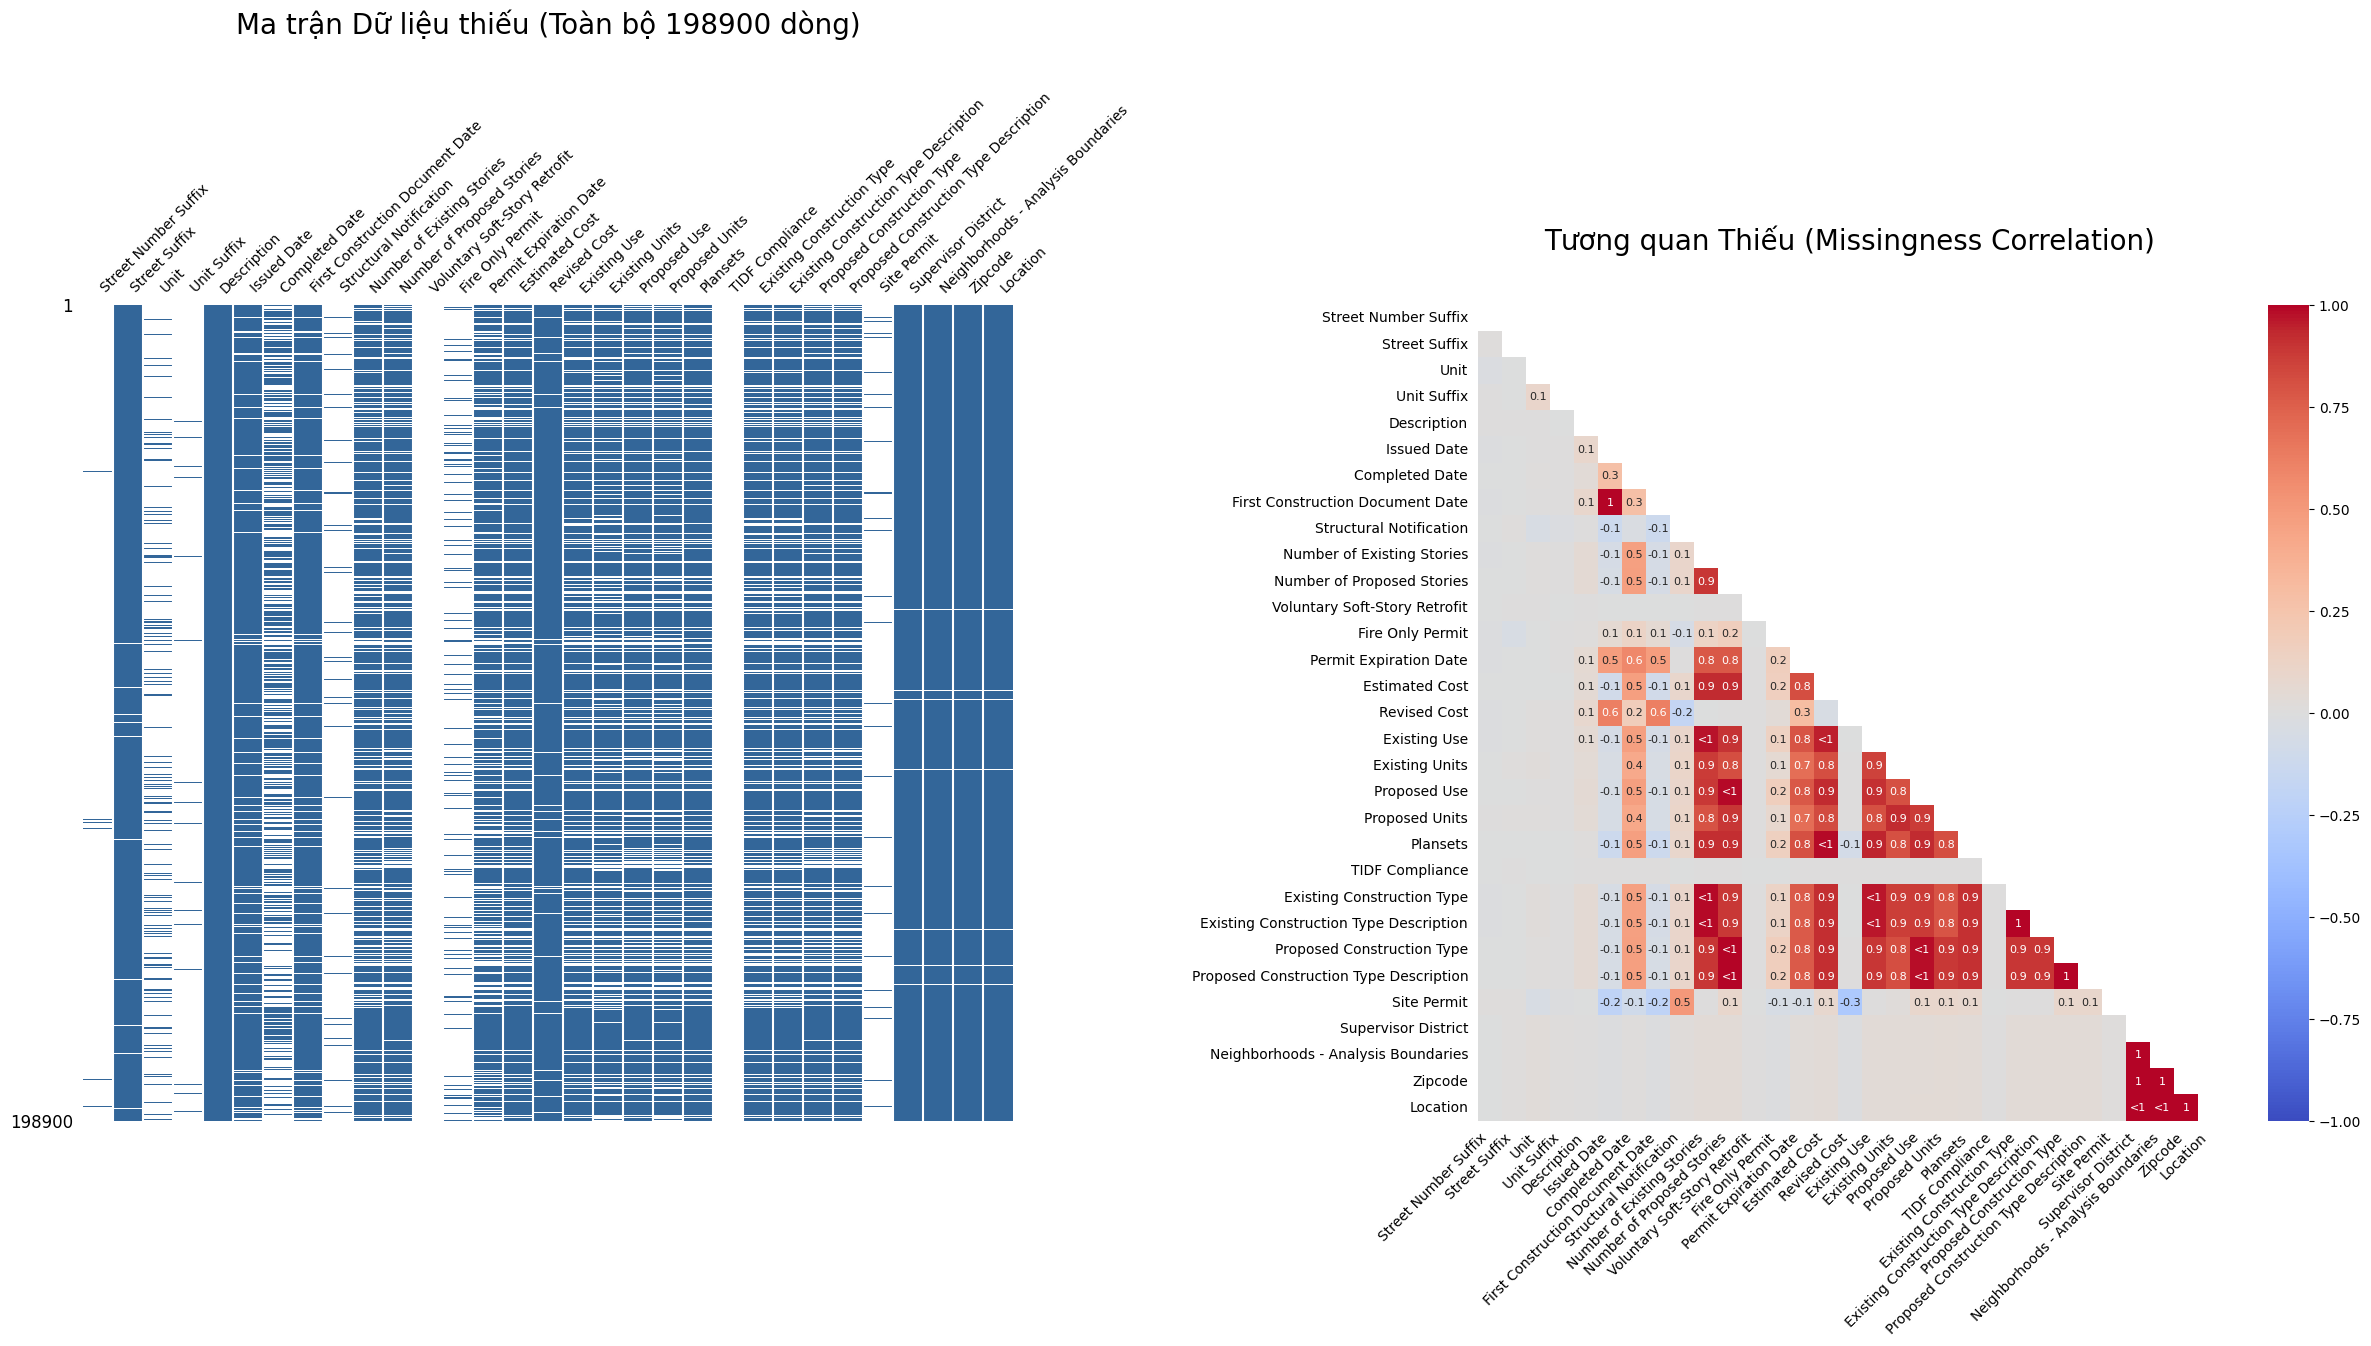


## Nhận xét: Trực quan hóa Dữ liệu Thiếu (Missing Values)

### 1. Phân bố Dữ liệu theo Cột
- **Cột cần loại bỏ (Thiếu > 40.0%):** `Street Number Suffix` (98.9%), `Unit` (85.2%), `Unit Suffix` (99.0%), `Completed Date` (51.1%), `Structural Notification` (96.5%), `Voluntary Soft-Story Retrofit` (100.0%), `Fire Only Permit` (90.5%), `TIDF Compliance` (100.0%), `Site Permit` (97.3%)
  > Các cột này thiếu quá nhiều thông tin, nếu fill (điền) sẽ sinh ra nhiễu lớn làm sai lệch mô hình. Khuyến nghị `drop`.
- **Cột thiếu ít/vừa (Có thể fill):** `Street Suffix` (1.4%), `Description` (0.1%), `Issued Date` (7.5%), `First Construction Document Date` (7.5%), `Number of Existing Stories` (21.5%)...

### 2. Phân bố Dữ liệu theo Dòng
- Có dòng bị thiếu tối đa **29** biến cùng lúc.
- Số lượng dòng bị thiếu quá nửa số biến (>50% số cột): **32164** dòng.
  > *Nhận xét:* Các dòng thiếu quá nhiều biến khả năng cao là dữ liệu rác hoặc hồ sơ bị hủy giữa chừng. Nên xóa các dòng này trước khi Train model. Nhìn vào biểu đồ Matrix (bên trái), nếu các dải màu trắng vạch ngang qua toàn bộ, chứng tỏ missing có xu hướng "tụm lại" ở các hồ sơ hỏng.

### 3. Tương quan Dữ liệu Thiếu (Missingness Correlation)
Phát hiện các cặp biến **rủ nhau cùng thiếu**:
  - `First Construction Document Date` & `Issued Date` (r = 1.00)
  - `Number of Proposed Stories` & `Number of Existing Stories` (r = 0.90)
  - `Permit Expiration Date` & `Number of Existing Stories` (r = 0.77)
  - `Permit Expiration Date` & `Number of Proposed Stories` (r = 0.77)
  - `Estimated Cost` & `Number of Existing Stories` (r = 0.92)
  - `Estimated Cost` & `Number of Proposed Stories` (r = 0.92)
  - `Estimated Cost` & `Permit Expiration Date` (r = 0.82)
  - `Existing Use` & `Number of Existing Stories` (r = 0.97)
  - `Existing Use` & `Number of Proposed Stories` (r = 0.90)
  - `Existing Use` & `Permit Expiration Date` (r = 0.80)
  - `Existing Use` & `Estimated Cost` (r = 0.95)
  - `Existing Units` & `Number of Existing Stories` (r = 0.88)
  - `Existing Units` & `Number of Proposed Stories` (r = 0.82)
  - `Existing Units` & `Estimated Cost` (r = 0.82)
  - `Existing Units` & `Existing Use` (r = 0.86)
  - `Proposed Use` & `Number of Existing Stories` (r = 0.88)
  - `Proposed Use` & `Number of Proposed Stories` (r = 0.99)
  - `Proposed Use` & `Permit Expiration Date` (r = 0.78)
  - `Proposed Use` & `Estimated Cost` (r = 0.93)
  - `Proposed Use` & `Existing Use` (r = 0.91)
  - `Proposed Use` & `Existing Units` (r = 0.81)
  - `Proposed Units` & `Number of Existing Stories` (r = 0.80)
  - `Proposed Units` & `Number of Proposed Stories` (r = 0.89)
  - `Proposed Units` & `Estimated Cost` (r = 0.82)
  - `Proposed Units` & `Existing Use` (r = 0.81)
  - `Proposed Units` & `Existing Units` (r = 0.93)
  - `Proposed Units` & `Proposed Use` (r = 0.88)
  - `Plansets` & `Number of Existing Stories` (r = 0.92)
  - `Plansets` & `Number of Proposed Stories` (r = 0.92)
  - `Plansets` & `Permit Expiration Date` (r = 0.81)
  - `Plansets` & `Estimated Cost` (r = 0.99)
  - `Plansets` & `Existing Use` (r = 0.94)
  - `Plansets` & `Existing Units` (r = 0.81)
  - `Plansets` & `Proposed Use` (r = 0.92)
  - `Plansets` & `Proposed Units` (r = 0.82)
  - `Existing Construction Type` & `Number of Existing Stories` (r = 0.99)
  - `Existing Construction Type` & `Number of Proposed Stories` (r = 0.89)
  - `Existing Construction Type` & `Permit Expiration Date` (r = 0.77)
  - `Existing Construction Type` & `Estimated Cost` (r = 0.92)
  - `Existing Construction Type` & `Existing Use` (r = 0.96)
  - `Existing Construction Type` & `Existing Units` (r = 0.87)
  - `Existing Construction Type` & `Proposed Use` (r = 0.88)
  - `Existing Construction Type` & `Proposed Units` (r = 0.79)
  - `Existing Construction Type` & `Plansets` (r = 0.91)
  - `Existing Construction Type Description` & `Number of Existing Stories` (r = 0.99)
  - `Existing Construction Type Description` & `Number of Proposed Stories` (r = 0.89)
  - `Existing Construction Type Description` & `Permit Expiration Date` (r = 0.77)
  - `Existing Construction Type Description` & `Estimated Cost` (r = 0.92)
  - `Existing Construction Type Description` & `Existing Use` (r = 0.96)
  - `Existing Construction Type Description` & `Existing Units` (r = 0.87)
  - `Existing Construction Type Description` & `Proposed Use` (r = 0.88)
  - `Existing Construction Type Description` & `Proposed Units` (r = 0.79)
  - `Existing Construction Type Description` & `Plansets` (r = 0.91)
  - `Existing Construction Type Description` & `Existing Construction Type` (r = 1.00)
  - `Proposed Construction Type` & `Number of Existing Stories` (r = 0.89)
  - `Proposed Construction Type` & `Number of Proposed Stories` (r = 0.99)
  - `Proposed Construction Type` & `Permit Expiration Date` (r = 0.77)
  - `Proposed Construction Type` & `Estimated Cost` (r = 0.92)
  - `Proposed Construction Type` & `Existing Use` (r = 0.90)
  - `Proposed Construction Type` & `Existing Units` (r = 0.81)
  - `Proposed Construction Type` & `Proposed Use` (r = 0.98)
  - `Proposed Construction Type` & `Proposed Units` (r = 0.89)
  - `Proposed Construction Type` & `Plansets` (r = 0.91)
  - `Proposed Construction Type` & `Existing Construction Type` (r = 0.89)
  - `Proposed Construction Type` & `Existing Construction Type Description` (r = 0.89)
  - `Proposed Construction Type Description` & `Number of Existing Stories` (r = 0.89)
  - `Proposed Construction Type Description` & `Number of Proposed Stories` (r = 0.99)
  - `Proposed Construction Type Description` & `Permit Expiration Date` (r = 0.77)
  - `Proposed Construction Type Description` & `Estimated Cost` (r = 0.92)
  - `Proposed Construction Type Description` & `Existing Use` (r = 0.90)
  - `Proposed Construction Type Description` & `Existing Units` (r = 0.81)
  - `Proposed Construction Type Description` & `Proposed Use` (r = 0.98)
  - `Proposed Construction Type Description` & `Proposed Units` (r = 0.89)
  - `Proposed Construction Type Description` & `Plansets` (r = 0.91)
  - `Proposed Construction Type Description` & `Existing Construction Type` (r = 0.89)
  - `Proposed Construction Type Description` & `Existing Construction Type Description` (r = 0.89)
  - `Proposed Construction Type Description` & `Proposed Construction Type` (r = 1.00)
  - `Neighborhoods - Analysis Boundaries` & `Supervisor District` (r = 1.00)
  - `Zipcode` & `Supervisor District` (r = 1.00)
  - `Zipcode` & `Neighborhoods - Analysis Boundaries` (r = 1.00)
  - `Location` & `Supervisor District` (r = 0.99)
  - `Location` & `Neighborhoods - Analysis Boundaries` (r = 0.99)
  - `Location` & `Zipcode` (r = 1.00)
  > *Ý nghĩa:* Quá trình thu thập có tính hệ thống (ví dụ: Nếu không có giấy phép xây dựng thì cũng không có ngày bắt đầu thi công).



--- BƯỚC 2: KIỂM ĐỊNH LITTLE'S MCAR TEST ---



## Nhận xét: Kiểm định Little's MCAR (Missing Completely At Random)
*(Sử dụng Kiểm định Toàn cục Chi-Square D²)*

### 1. Kết quả Thống kê
- **Giả thuyết H0:** Sự thiếu dữ liệu là hoàn toàn ngẫu nhiên (MCAR).
- **Giá trị Chi-Square ($\chi^2$):** `-10646.9837`
- **Bậc tự do (df):** `1207`
- **p-Value:** `1.0000e+00` (Alpha = `0.05`)

### 2. Kết luận
- **KẾT LUẬN: Dữ liệu bị thiếu hoàn toàn ngẫu nhiên (MCAR).**

### 3. Diễn giải & Hướng xử lý
- Dựa vào kiểm định Little's MCAR (1988), p-value lớn hơn mức ý nghĩa Alpha. Ta chấp nhận giả thuyết H0. Sự thiếu hụt dữ liệu không có tính hệ thống. 

👉 **Khuyến nghị:** Bạn có thể an tâm sử dụng các phương pháp đơn giản như điền Mean, Median, Mode hoặc Listwise Deletion (xóa dòng) mà không sợ làm sai lệch phân phối gốc của tập dữ liệu.


In [1]:
import os
import sys
if os.path.abspath(os.path.join('..', 'src')) not in sys.path:
    sys.path.append(os.path.abspath(os.path.join('..', 'src')))
import sys
import os
import warnings

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

from table.dataset import TableDataset
from statistic.test_missing import MCARLittleTesting
from table.analysis_missing_value import MissingValueMatrix 
from config.settings import PATH_FOLDER_TABLE_RAW
from pathlib import Path
dataset = TableDataset(str(Path(PATH_FOLDER_TABLE_RAW) / "Building_Permits.csv"))
print("--- BƯỚC 1: TRỰC QUAN HÓA BẰNG MA TRẬN ---")
matrix_vis = MissingValueMatrix(drop_threshold=40.0) 
matrix_vis.visitTableDataset(dataset)  
matrix_vis.run() 
print("\n--- BƯỚC 2: KIỂM ĐỊNH LITTLE'S MCAR TEST ---")
mcar_tester = MCARLittleTesting(alpha=0.05)
mcar_tester.visitTableDataset(dataset)  
mcar_tester.run()  